# Online Design Experiment Tutorial

This tutorial demonstrates how to run an online design experiment using the ALF (Active Learning Framework) codebase. We'll walk through the complete process of setting up and running an online active learning experiment for protein design using physics-based scoring with PyRosetta.

### What is an Online Design Experiment?

An online design experiment is a type of active learning experiment where we query a real oracle (such as a physics simulator or wet-lab experiment) to obtain ground truth labels in real time. Unlike offline experiments that use a fixed dataset, online experiments:
- Generate new labels on-the-fly as sequences are proposed
- Can explore beyond pre-existing labeled data
- More closely simulate real-world experimental campaigns
- Are typically more computationally expensive per query

### Experiment Overview

In this tutorial, we'll:
1. Set up a protein structure and PyRosetta physics-based oracle
2. Train a CNN surrogate model to approximate the expensive physics calculations
3. Use an acquisition strategy to select promising sequences for evaluation
4. Run multiple rounds of active learning with real oracle queries
5. Analyze how efficiently we discover high-fitness proteins compared to random search

### Framework Components

Before we start, let's understand the key components of the ALF framework:

1. **Dataset** (`ProteinGym`): Contains initial labeled data for training. Handles data splitting into train/validation/test sets. In online experiments, the candidate pool is empty since candidates are generated rather than pre-defined.

2. **Surrogate Model** (`CNNModel`): Trained on labeled data to approximate the expensive oracle evaluation and guide candidate selection.

3. **Search Strategy** (`SingleMutantSearch`): Generates new candidate sequences by systematically mutating the current best sequence. Unlike offline experiments, candidates are created on-the-fly rather than drawn from a fixed pool.

4. **Acquisition Function** (`Greedy`): Determines which generated sequences are most promising to evaluate next based on surrogate model predictions.

5. **Optimizer** (`Optimizer`): Combines acquisition function and search strategy and handles the "ask" (generate and select candidates) and "tell" (update surrogate with results) cycle.

6. **Oracle** (`PyRosetta`): The evaluation function - a physics-based energy scorer that computes fitness values for proposed sequences. Unlike offline experiments, this is a true oracle query, not a dataset lookup.

7. **Task** (`DesignTask`): Orchestrates the entire active learning loop, managing multiple acquisition rounds, oracle queries, and model updates.

### Step 0: Environment Setup

First, let's set up the Python environment using `uv` and the project's `pyproject.toml`. This will install all required dependencies including `alf_core`, `alf_tools`, and other necessary packages.


To create an environment and install the required dependencies run:

```
uv sync
```

from the `/tutorials` directory. You can also run `uv sync --extra torch_gpu` or `uv sync --extra torch_cpu` to install the dependencies for GPU or CPU respectively.

To activate your environment use `source .venv/bin/activate` from the tutorials directory. When starting the notebook, select .venv when prompted to select a kernel.

### Step 1: Import Required Libraries

Let's start by importing all the necessary components from the ALF framework:


In [1]:
# Core framework imports
import shutil

import matplotlib.pyplot as plt

# Additional imports for analysis
import pandas as pd
from alf_core import (
    DesignTask,
    FileTaskStateLogger,
    Optimizer,
    Oracle,
    ProtocolSearch,
    Surrogate,
    TerminalTaskStateLogger,
)
from alf_tools.datasets import GFP
from alf_tools.models import CNNModel
from alf_tools.optimizer.acquisition_functions import Greedy
from alf_tools.optimizer.search import SingleMutantSearch

print("✅ All imports successful!")

/Users/c.finlay/Desktop/alf/tutorials/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All imports successful!


In [2]:
from dotenv import load_dotenv

load_dotenv()

True

### Step 2: Configure the Dataset

The GFP dataset contains protein sequences and their measured brightness values. Let's set up the dataset with appropriate splits:


In [3]:
# Dataset configuration
split_config = {
    "split_ratio": {
        "train": 0.1,  # 10% for initial training
        "validation_frac": 0.2,  # 10% of training data for validation
        "test": 0.1,  # 10% for final evaluation
    },
    "split_type": "random",  # Random split for reproducibility
}

# Initialize the GFP dataset
gfp_dataset = GFP(
    name="gfp",
    modality="sequence",  # We're working with protein sequences
    seed=51505,  # For reproducibility
    split_config=split_config,
)

print("✅ Dataset initialized!")
print("📊 Dataset info:")
print(f"   - Total sequences: {len(gfp_dataset._raw_dataset)}")
print(f"   - Sequence length: {len(gfp_dataset._raw_dataset.data[0])}")
print(
    f"   - Fitness score range: {gfp_dataset._raw_dataset.labels.min():.2f} to"
    f" {gfp_dataset._raw_dataset.labels.max():.2f}"
)

✅ Dataset initialized!
📊 Dataset info:
   - Total sequences: 1000
   - Sequence length: 714
   - Fitness score range: 1.29 to 4.03


### Step 3: Initialize the Surrogate Model

The surrogate model is a CNN that learns to predict protein fitness from sequence. This is the "brain" of our active learning system:


In [4]:
# Initialize the CNN surrogate model
surrogate = Surrogate(model=CNNModel())

print("✅ Surrogate model initialized!")
print("🧠 Model architecture:")
print("   - Type: 1D Convolutional Neural Network")
print("   - Input: One-hot encoded protein sequences")
print("   - Output: Predicted fitness values")
print("   - Purpose: Learn sequence → fitness mapping")

✅ Surrogate model initialized!
🧠 Model architecture:
   - Type: 1D Convolutional Neural Network
   - Input: One-hot encoded protein sequences
   - Output: Predicted fitness values
   - Purpose: Learn sequence → fitness mapping


### Step 4: Set Up the Acquisition Strategy

The acquisition function determines which sequences are most promising to evaluate next. We'll use a simple greedy strategy:


In [5]:
# Initialize acquisition function (greedy strategy)
acquisition_fn = Greedy()

print("✅ Acquisition function initialized!")
print("🎯 Strategy: Greedy selection")
print("   - Selects sequences with highest predicted fitness")
print("   - Simple but effective for many design tasks")
print("   - Alternative strategies: UCB, Thompson sampling, etc.")

✅ Acquisition function initialized!
🎯 Strategy: Greedy selection
   - Selects sequences with highest predicted fitness
   - Simple but effective for many design tasks
   - Alternative strategies: UCB, Thompson sampling, etc.


### Step 5: Configure the Search Strategy

The search strategy defines where we can look for new sequences. In offline experiments, we search within the unlabeled portion of our dataset:


In [6]:
# Initialize search strategy
search_fn = ProtocolSearch(protocol=SingleMutantSearch())

print("✅ Search strategy initialized!")
print("🔍 Strategy: Single mutant search")
print("   - Generates all single-point mutations of the best sequence")
print("   - Explores local neighborhood around current best")
print("   - Efficient for incremental improvement of sequences")

✅ Search strategy initialized!
🔍 Strategy: Single mutant search
   - Generates all single-point mutations of the best sequence
   - Explores local neighborhood around current best
   - Efficient for incremental improvement of sequences


### Step 6: Create the Optimizer

The optimizer combines the acquisition function and search strategy to handle the ask-tell cycle:


In [7]:
# Initialize optimizer
optimizer = Optimizer(acquisition_fn=acquisition_fn, search_fn=search_fn)

print("✅ Optimizer initialized!")
print("⚙️ Optimizer components:")
print("   - Acquisition function: Greedy selection")
print("   - Search strategy: Dataset-based search")
print("   - Handles: ask() → select candidates, tell() → update surrogate with results")

✅ Optimizer initialized!
⚙️ Optimizer components:
   - Acquisition function: Greedy selection
   - Search strategy: Dataset-based search
   - Handles: ask() → select candidates, tell() → update surrogate with results


### Step 7: Set Up the Oracle

The oracle simulates the expensive experimental evaluation. In offline experiments, it provides ground truth labels from the dataset:


In [8]:
import subprocess
import sys

import pyrosetta_installer

os_name = pyrosetta_installer.get_pyrosetta_os()
base_url = pyrosetta_installer._PYROSETTA_RELEASES_URLS_[0]
python_version = f"python{sys.version_info.major}{sys.version_info.minor}"
url_base = f"{base_url}/PyRosetta4.Release.{python_version}.{os_name}.wheel/"
wheel_filename = pyrosetta_installer.get_latest_file(url_base)
wheel_url = url_base + wheel_filename

print(f"📦 Downloading PyRosetta wheel: {wheel_filename}")
print(
    f"🎯 Target environment: {sys.executable} "
    f"(Python {sys.version_info.major}.{sys.version_info.minor})"
)
print(
    "⏳ This will take ~30 minutes due to the large package size if running for the first time..."
)

# Install using uv to the correct environment
subprocess.check_call(["uv", "pip", "install", wheel_url])
subprocess.check_call(["uv", "pip", "install", "numpy"])

print("✓ PyRosetta installed successfully!")

# Verify it worked
import pyrosetta  # noqa: E402

print(f"✓ PyRosetta imported from: {pyrosetta.__file__}")

📦 Downloading PyRosetta wheel: pyrosetta-2025.49+release.552382f5ef-cp313-cp313-macosx_12_0_arm64.whl
🎯 Target environment: /Users/c.finlay/Desktop/alf/tutorials/.venv/bin/python (Python 3.13)
⏳ This will take ~30 minutes due to the large package size if running for the first time...
✓ PyRosetta installed successfully!


Audited 1 package in 15ms
Audited 1 package in 1ms


✓ PyRosetta imported from: /Users/c.finlay/Desktop/alf/tutorials/.venv/lib/python3.13/site-packages/pyrosetta/__init__.py


In [17]:
import gzip
import os
import urllib.request

from alf_tools.models.pyrosetta import PyRosetta

# Download structure from PDB
dms_structure_name = "GFP"
pdb_url = "https://files.wwpdb.org/pub/pdb/data/structures/divided/pdb/gf/pdb1gfl.ent.gz"
local_path = f"structures/{dms_structure_name}.pdb"

os.makedirs("structures", exist_ok=True)
if not os.path.exists(local_path):
    print(f"Downloading {pdb_url}...")
    gz_path = local_path + ".gz"
    urllib.request.urlretrieve(pdb_url, gz_path)
    
    # Decompress the gzipped file
    with gzip.open(gz_path, 'rb') as f_in:
        with open(local_path, 'wb') as f_out:
            f_out.write(f_in.read())
    
    # Remove the compressed file
    os.remove(gz_path)
    print(f"✅ Saved to {local_path}")

# Create model
model = PyRosetta(pdb_path=local_path, initial_relax_repeats=5, seed=0)

oracle = Oracle(scorer=model)

✅ Saved to structures/GFP.pdb
┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2025 [Rosetta PyRosetta4.Release.python313.m1 2025.49+release.552382f5ef84f3c058ac922b717ceee014073be6 2025-12-04T19:34:13] retrieved from: http://www.pyrosetta.org
core.init: Checking for fconfig files in pwd and ./rosetta/flags
core.init: Rosetta version: PyRosetta4.Release.python313.m1 r418 2025.49

### Step 8: Configure the Design Task

Now we'll set up the main design task that orchestrates the entire active learning process:


In [ ]:
# Configure the design task
num_acq_rounds = 1  # Number of active learning rounds
acq_batch_size = 5  # Number of sequences to acquire per round

task = DesignTask(num_acq_rounds=num_acq_rounds, acq_batch_size=acq_batch_size)

print("✅ Design task configured!")
print("📋 Experiment parameters:")
print(f"   - Acquisition rounds: {num_acq_rounds}")
print(f"   - Batch size per round: {acq_batch_size}")
print(f"   - Total sequences to acquire: {num_acq_rounds * acq_batch_size}")
print("   - Task type: Online design optimization")

✅ Design task configured!
📋 Experiment parameters:
   - Acquisition rounds: 5
   - Batch size per round: 10
   - Total sequences to acquire: 50
   - Task type: Online design optimization


### Step 9: Run the Online Design Experiment

Now let's run the complete experiment! This will:
1. Set up the initial state with training data
2. Run multiple rounds of active learning
3. Track performance metrics throughout


In [ ]:
from pathlib import Path

# Initialize logger for tracking metrics
terminal_logger = TerminalTaskStateLogger()
save_path = Path("results/online_design/")
if save_path.exists():
    shutil.rmtree(save_path)
file_logger = FileTaskStateLogger(output_path=save_path)
loggers = [terminal_logger, file_logger]

# Set up the initial state
print("🚀 Setting up experiment...")
state = task.setup(dataset=gfp_dataset, surrogate=surrogate)

print("📊 Initial state:")
print(f"   - Training samples: {len(state.dataset.train_dataset)}")
print(f"   - Validation samples: {len(state.dataset.validation_dataset)}")
print(f"   - Test samples: {len(state.dataset.test_dataset)}")
print(f"   - Unlabeled samples: {len(state.dataset.candidate_pool)}")

# Run the active learning experiment
print("\n🔄 Starting online active learning experiment...")
print("=" * 50)

task.run(state, task_state_loggers=loggers, optimizer=optimizer, oracle=oracle)

print("\n✅ Experiment completed!")

🚀 Setting up experiment...
📊 Initial state:
   - Training samples: 120
   - Validation samples: 30
   - Test samples: 100
   - Unlabeled samples: 798

🔄 Starting online active learning experiment...
core.scoring.ScoreFunctionFactory: SCOREFUNCTION: ref2015
core.pack.task: Packer task: initialize from command line()
core.pack.pack_rotamers: built 1 rotamers at 1 positions.
core.pack.interaction_graph.interaction_graph_factory: Instantiating PDInteractionGraph
core.scoring.ScoreFunctionFactory: SCOREFUNCTION: ref2015
core.pack.task: Packer task: initialize from command line()
core.pack.pack_rotamers: built 6 rotamers at 1 positions.
core.pack.interaction_graph.interaction_graph_factory: Instantiating PDInteractionGraph
core.scoring.ScoreFunctionFactory: SCOREFUNCTION: ref2015
core.pack.task: Packer task: initialize from command line()
core.pack.pack_rotamers: built 1 rotamers at 1 positions.
core.pack.interaction_graph.interaction_graph_factory: Instantiating PDInteractionGraph
core.scor

### Step 10: Analyze the Results

After the experiment completes, we can load the saved metrics and visualize the optimization progress. We track:
- **Round Mean Fitness**: Average fitness of selected sequences in each acquisition batch
- **Round Maximum Fitness**: Highest fitness value among sequences selected in each round

If the optimization is working well, these metrics should increase over rounds as we discover better sequences.

In [ ]:
# Load metrics from CSV
metrics = pd.read_csv("results/online_design/metrics.csv")
# print summary statistics
print("Experiment Summary:")
print(f"Total Rounds (including zeroth round): {len(metrics)}")
print(f"Initial Mean Fitness: {metrics['acquired_candidates/round_mean'].iloc[1]:.4f}")
print(f"Final Mean Fitness: {metrics['acquired_candidates/round_mean'].iloc[-1]:.4f}")
print(f"Best Fitness Found: {metrics['acquired_candidates/round_max'].max():.4f}")

FileNotFoundError: [Errno 2] No such file or directory: 'results/online_design/metrics.csv'

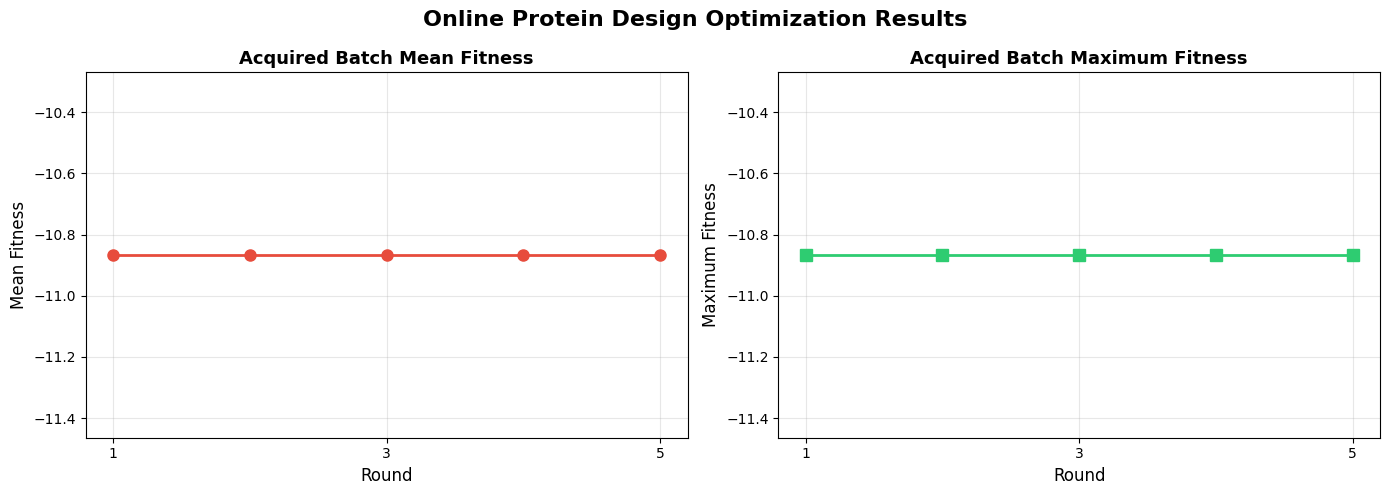

In [ ]:
# Create visualization of results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Online Protein Design Optimization Results", fontsize=16, fontweight="bold")

# Filter out the zeroth round (first row)
metrics_plot = metrics.iloc[1:]

# 1. Round Mean Fitness (quality of acquired batch each round)
axes[0].plot(
    metrics_plot["round"],
    metrics_plot["acquired_candidates/round_mean"],
    marker="o",
    linewidth=2,
    markersize=8,
    color="#e74c3c",
)
axes[0].set_xlabel("Round", fontsize=12)
axes[0].set_ylabel("Mean Fitness", fontsize=12)
axes[0].set_title("Acquired Batch Mean Fitness", fontsize=13, fontweight="bold")
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(metrics_plot["round"][::2])

# 2. Round Maximum Fitness (best fitness in acquired batch each round)
axes[1].plot(
    metrics_plot["round"],
    metrics_plot["acquired_candidates/round_max"],
    marker="s",
    linewidth=2,
    markersize=8,
    color="#2ecc71",
)
axes[1].set_xlabel("Round", fontsize=12)
axes[1].set_ylabel("Maximum Fitness", fontsize=12)
axes[1].set_title("Acquired Batch Maximum Fitness", fontsize=13, fontweight="bold")
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(metrics_plot["round"][::2])

plt.tight_layout()
plt.show()

In [14]:
# Optionally, clean up the results directory
if save_path.exists():
    shutil.rmtree(save_path)

print("✅ Results directory cleaned up!")

✅ Results directory cleaned up!


## Conclusion

This tutorial has demonstrated how to run an **online design experiment** using the ALF framework. We've learned:

- **What online design experiments are** and how they differ from offline experiments
- **How to set up a physics-based oracle** (PyRosetta) for real-time sequence evaluation
- **How to use generative search strategies** (SingleMutantSearch) that propose novel candidates beyond a fixed pool
- **How to run a complete active learning loop** with real oracle queries at each round
- **How to analyze the results** to evaluate experimental efficiency and optimization progress

The key distinction from offline experiments is that online design queries a real oracle (physics simulator, wet-lab, etc.) to obtain labels in real time, rather than looking up pre-computed values from a dataset. This makes online experiments more realistic simulations of actual experimental campaigns, but also more computationally expensive per query.

The ALF framework provides a flexible and modular approach to active learning that can be adapted to many different design problems. Whether you're working on protein design, drug discovery, materials science, or other optimization tasks, the principles demonstrated here can be applied to guide efficient experimental design.

**Happy designing!** 🧬🔬✨